# ПЕРЕВОД Описания датасета со странички kaggle:

## Общая информация
Данный датасет содержит данные о маркетинговых кампаниях португальского банка.  
Кампании проводились с помощью телефонных звонков клиентам.

Цель кампании — предложить клиенту банковский продукт: срочный депозит (term deposit)

В некоторых случаях для одного клиента требовалось несколько контактов, чтобы получить результат.

---

## Целевая переменная

y — оформил ли клиент депозит:
- `yes` — да
- `no` — нет
- 
Это задача бинарной классификации.

---

## Данные о клиенте

- age — возраст (числовой)
- job — тип работы:  admin, technician, services и др.
- marital — семейное положение: married, single, divorced, unknown
- education — уровень образования: school, university, professional и др.
- default — есть ли просроченный кредит: yes / no / unknown
- housing — есть ли ипотека: yes / no / unknown
- loan — есть ли потребительский кредит: yes / no / unknown

---

## Информация о последнем контакте

- contact — тип связи:  cellular (мобильный)  /  telephone (стационарный)
- month — месяц контакта
- day_of_week — день недели
- duration — длительность звонка (в секундах)

Важно:
Переменная `duration` сильно влияет на результат,  
но она неизвестна до звонка, поэтому:
- её нельзя использовать в реальной модели
- можно использовать только для анализа

---

## История взаимодействий с клиентом

- campaign — количество контактов в текущей кампании
- pdays — сколько дней прошло с прошлого контакта: 999 = клиент ранее не контактировался
- previous — количество контактов до текущей кампании
- poutcome — результат прошлой кампании: success / failure / nonexistent

---

## Макроэкономические показатели

- emp.var.rate — уровень изменения занятости
- cons.price.idx — индекс потребительских цен
- cons.conf.idx — индекс доверия потребителей
- euribor3m — ставка Euribor (3 месяца)
- nr.employed — количество занятых

---

## Бизнес-контекст задачи

Банк хочет:
- увеличить конверсию в депозит
- оптимизировать маркетинговые кампании
- понять, кому стоит звонить

---

## Возможные задачи анализа

- Какие клиенты чаще соглашаются на депозит?
- Влияет ли количество звонков на успех?
- Какие каналы коммуникации эффективнее?
- Когда лучше звонить (месяц / день)?
- Как прошлые кампании влияют на текущую?

---

## Особенности датасета

- сильный дисбаланс классов (мало `yes`)
- есть категориальные признаки
- есть признаки, которые нельзя использовать в продакшене (`duration`)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Сначала посмотрим что из себя представляет датасет по первым записям
df = pd.read_csv("bank_marketing.csv", sep=";")
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Посмотрим общую информацию 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [4]:
# Попробуем найти выбивающиеся значения из описания
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
# Проверка на явные Null и пропуски
print(df.isnull().sum())
df.isnull().mean() * 100

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


age               0.0
job               0.0
marital           0.0
education         0.0
default           0.0
housing           0.0
loan              0.0
contact           0.0
month             0.0
day_of_week       0.0
duration          0.0
campaign          0.0
pdays             0.0
previous          0.0
poutcome          0.0
emp.var.rate      0.0
cons.price.idx    0.0
cons.conf.idx     0.0
euribor3m         0.0
nr.employed       0.0
y                 0.0
dtype: float64

Гипотеза 1. Существует точка невозврата - количество звонков, после которого вероятность согласия стремится к нулю, а затраты растут.
Попробуем проверить эту гипотезу с помощью количества контактов в текущей компании

In [6]:
# посчитаем сколько звонков в текущей кампании было и сколько было успешных
campaign_grouped = df.groupby('campaign')['y'].agg([
    ('total_calls', 'count'),
    ('success', lambda x: (x=='yes').sum())
]).reset_index()

# рассчитаем конверсию успешных звонков
campaign_grouped['cr'] = campaign_grouped['success'] / campaign_grouped['total_calls'] * 100


# рассчитаем кумулятивный процент успеха
total_yes = campaign_grouped['success'].sum()
campaign_grouped['cumulative_success_rate'] = (campaign_grouped['success'].cumsum() / total_yes) * 100
campaign_grouped_vis = campaign_grouped[:15]
campaign_grouped_vis

,campaign,total_calls,success,cr,cumulative_success_rate
0,1,17642,2300,13.037071,49.568966
1,2,10570,1211,11.456954,75.668103
2,3,5341,574,10.747051,88.038793
3,4,2651,249,9.392682,93.405172
4,5,1599,120,7.504690,95.991379
5,6,979,75,7.660878,97.607759
6,7,629,38,6.041335,98.426724
7,8,400,17,4.250000,98.793103
8,9,283,17,6.007067,99.159483
9,10,225,12,5.333333,99.418103


Визуализируем рассчитанные метрики и сделаем вывод по графику и по рассчитанным метрикам

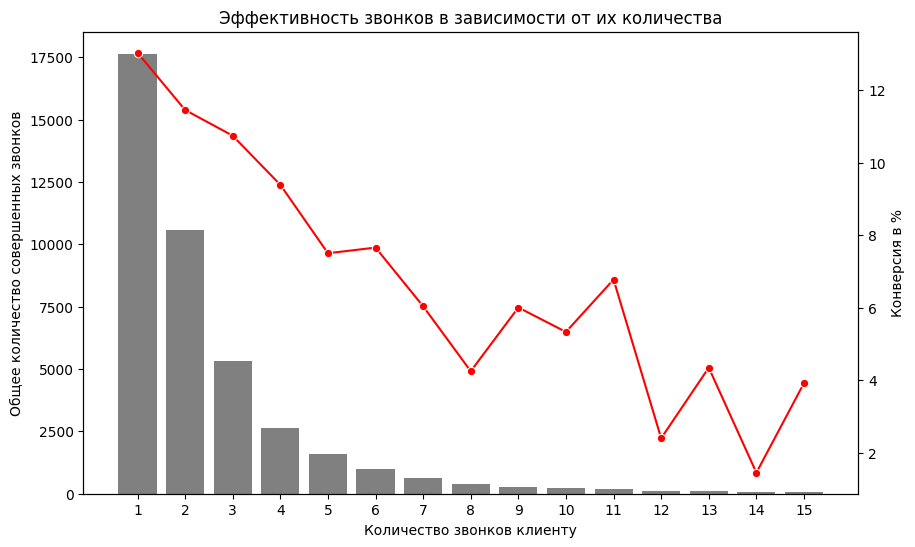

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(x='campaign',y='total_calls', data=campaign_grouped_vis, color='gray')
ax.set_ylabel("Общее количество совершенных звонков")
ax.set_xlabel("Количество звонков клиенту")

ax2 = ax.twinx()
sns.lineplot(x=campaign_grouped_vis.index,y='cr', data=campaign_grouped_vis, ax=ax2, color='red', marker='o')
ax2.set_ylabel('Конверсия в %')
plt.title("Эффективность звонков в зависимости от их количества")
plt.show()

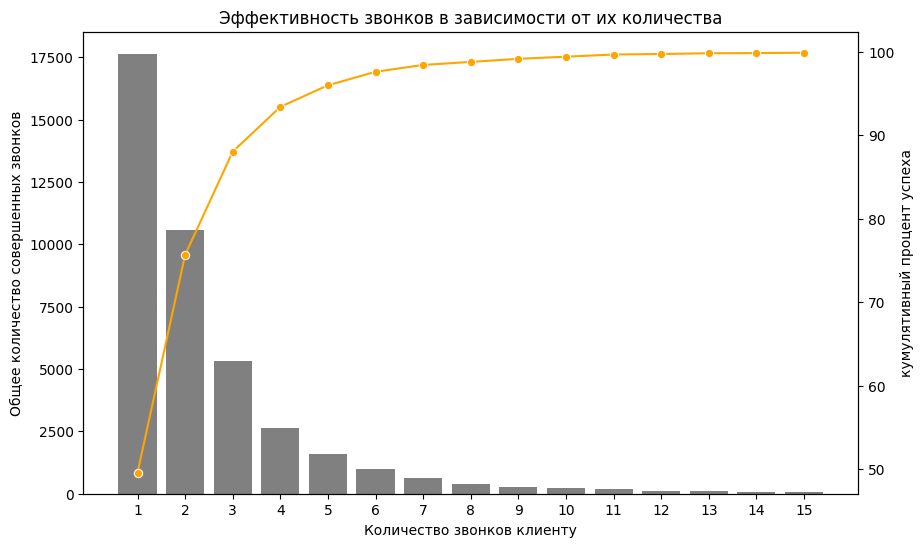

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(x='campaign',y='total_calls', data=campaign_grouped_vis, color='gray')
ax.set_ylabel("Общее количество совершенных звонков")
ax.set_xlabel("Количество звонков клиенту")

ax2 = ax.twinx()
sns.lineplot(x=campaign_grouped_vis.index,y='cumulative_success_rate', data=campaign_grouped_vis, ax=ax2, color='orange', marker='o')
ax2.set_ylabel('кумулятивный процент успеха')

plt.title("Эффективность звонков в зависимости от их количества")
plt.show()

In [9]:
total_useless_calls = campaign_grouped['total_calls'][7:].sum()
print(total_useless_calls)
calls_conv = (total_useless_calls / campaign_grouped['total_calls'].sum() * 100)
calls_conv

1777


np.float64(4.314363406817519)

По первому графику можно сделать вывод, что после шестого звонка становится бессмысленно звонить, так как в два раза падает конверсия 
Начиная с седьмого звонка она опускается еще ниже

По второму графику можно сделать вывод, что уже после перовго звонка банк получает почти 50 процентов всех депозотов, после третьего звонка 88 процентов, а после шестого 97.6 процентов результата
Оставшиеся звонки приносят всего 2.4 процента успеха, но отнимают огромное количество ресурсов операторов

Бизнес-решением будет ограничение лимита звонков до 6, чтобы сократить расходы на обзвон на 4.3%  и при этом сохранить почти весь объем продаж 

Гипотеза 2. Существует время, когда клиенты более лояльны и в это время нужно совершать звонки

In [10]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [11]:
# Добавим столбец для подсчета конверсий
df['binary_y'] = df['y'].map({'yes': 1, 'no': 0})


In [12]:
# построим сводные таблицы по датам и посчитаем в них конверсию по звонкам и так же количество звонков в эти даты
months = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
days = ['mon', 'tue', 'wed', 'thu', 'fri']
df_table = pd.pivot_table(df, index='month', columns='day_of_week', values='binary_y', aggfunc='mean')
df_table = df_table.reindex(index=months, columns=days)

df_table_counts = pd.pivot_table(df, index='month', columns='day_of_week', values='binary_y', aggfunc='count')
df_table_counts = df_table_counts.reindex(index=months, columns=days)

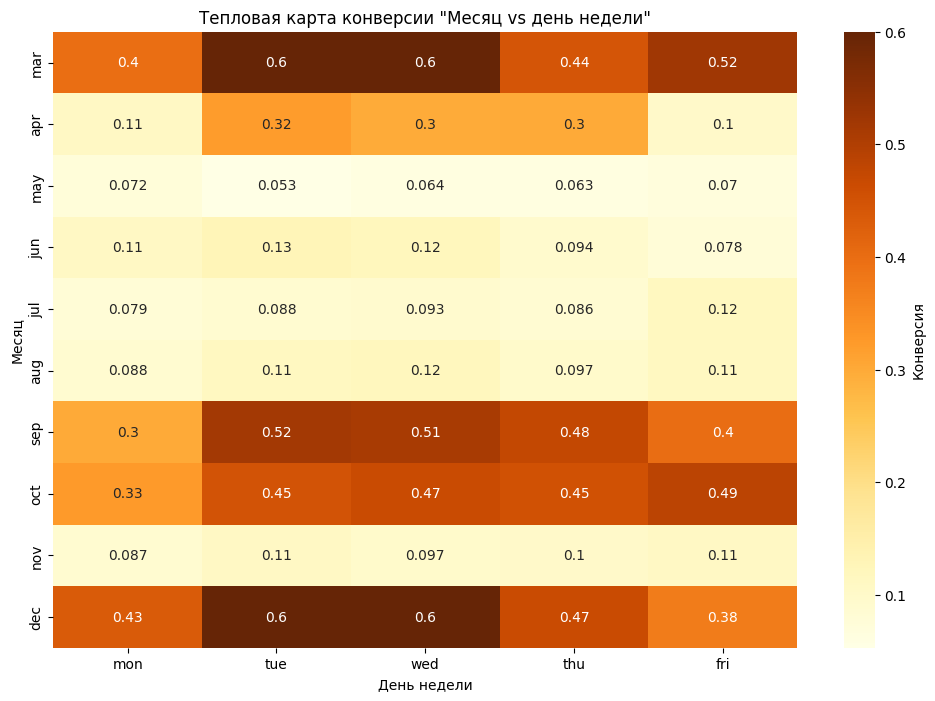

In [13]:
# Отобразим тепловую карту с посчитанной конверсией по датам
plt.figure(figsize=(12,8))
sns.heatmap(df_table, annot=True, cmap='YlOrBr',
           cbar_kws={'label': 'Конверсия'}
           )
plt.title('Тепловая карта конверсии "Месяц vs день недели"')
plt.xlabel('День недели')
plt.ylabel('Месяц')
plt.show()

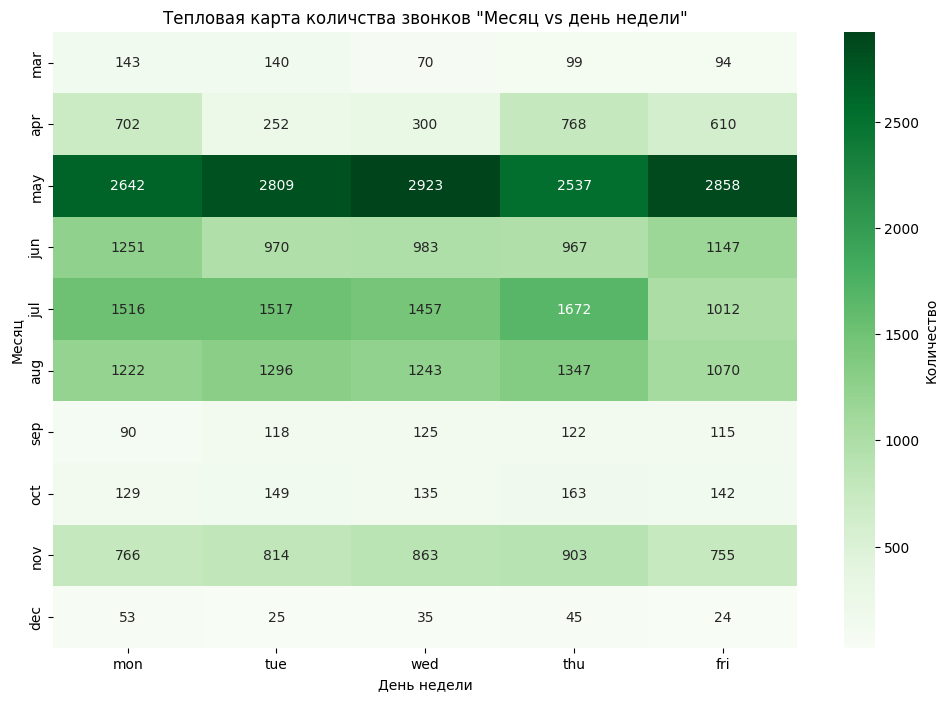

In [14]:
# Отобразим тепловую карту с количеством звонков по датам
plt.figure(figsize=(12,8))
sns.heatmap(df_table_counts, annot=True, fmt="d", cmap='Greens',
           cbar_kws={'label': 'Количество'}
           )
plt.title('Тепловая карта количства звонков "Месяц vs день недели"')
plt.xlabel('День недели')
plt.ylabel('Месяц')
plt.show()

Анализ хитмапов:
В мае самое большое количество звонков в год, при этом минимальная конверсия с этих звонков
В марте, сентябре, октябре и декабре самая высокая конверсия в году, но малое количество звонков, что может означать обработку только самых выгодных клиентов, а не всех подряд
В июне, июле и августе средние объемы по звонкам и конверсия держится на уровне 10 процентоа, это самый стабильный для оценки промежуток

Рекомендация: Пересмотреть стратегию звонков в майских кампаниях, нужно либо снижать интенсивность, либо изменить подход, так как текущий подход дает минимум пользы

Использовать опыт сентябрьских и октябрьских кампаний  с высокой конверсией для масштабирования, так как там объемы уже немного больше, но конверсия в 4-5 раз выше среднего

Гипотеза 3. Есть зависимость от возраста и типа связи с конверсией депозита
Сначала посмотрим сколько вообще значений по типам телефонных звонков

In [15]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,binary_y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


In [16]:
df['contact'].value_counts()

contact
cellular     26144
telephone    15044
Name: count, dtype: int64

Теперь разделим данные из датафрейма на возрастные группы

In [17]:
age_groups = [16, 24, 35, 44, 54, 64, 98]
group_names = [
    'студенты/ранняя карьера(16-24)', 'Молодые специалисты(24-35)','Зрелый возраст (35-44)',
    'Зрелый возраст 44-54)', 'Пожилой возраст(54-64)', 'Старческий возраст(64-98)'
]

df['age_group'] = pd.cut(df['age'], bins=age_groups, labels=group_names)
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,binary_y,age_group
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,Пожилой возраст(54-64)
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,Пожилой возраст(54-64)
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,Зрелый возраст (35-44)
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,Зрелый возраст (35-44)
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,Пожилой возраст(54-64)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,1,Старческий возраст(64-98)
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no,0,Зрелый возраст 44-54)
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no,0,Пожилой возраст(54-64)
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,1,Зрелый возраст (35-44)


In [18]:
df_grouped = df.groupby(['age_group', 'contact'])['binary_y'].mean().reset_index()
df_sum = df.groupby(['age_group', 'contact'])['binary_y'].sum().reset_index()
print(df_grouped)
print(df_sum)

                         age_group    contact  binary_y
0   студенты/ранняя карьера(16-24)   cellular  0.284160
1   студенты/ранняя карьера(16-24)  telephone  0.087137
2       Молодые специалисты(24-35)   cellular  0.150519
3       Молодые специалисты(24-35)  telephone  0.056438
4           Зрелый возраст (35-44)   cellular  0.113227
5           Зрелый возраст (35-44)  telephone  0.045670
6            Зрелый возраст 44-54)   cellular  0.112752
7            Зрелый возраст 44-54)  telephone  0.044696
8           Пожилой возраст(54-64)   cellular  0.179386
9           Пожилой возраст(54-64)  telephone  0.058275
10       Старческий возраст(64-98)   cellular  0.489002
11       Старческий возраст(64-98)  telephone  0.333333
                         age_group    contact  binary_y
0   студенты/ранняя карьера(16-24)   cellular       235
1   студенты/ранняя карьера(16-24)  telephone        21
2       Молодые специалисты(24-35)   cellular      1538
3       Молодые специалисты(24-35)  telephone   

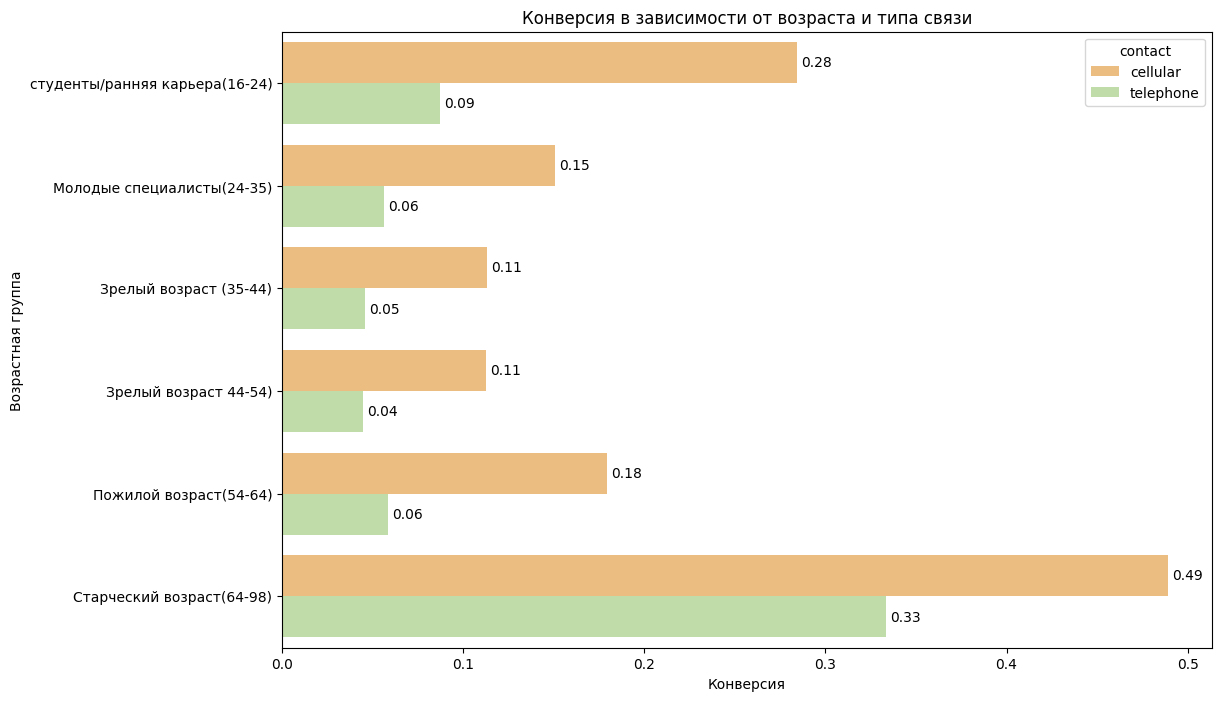

In [19]:
plt.figure(figsize=(12,8))
ax = sns.barplot(df_grouped, y='age_group', x='binary_y', hue='contact',palette='Spectral')

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

    

plt.title("Конверсия в зависимости от возраста и типа связи")
plt.xlabel("Конверсия")
plt.ylabel("Возрастная группа")
plt.show()

Вывод:

U-образная зависимость, которую можно описать вот так - максимальная готовность к открытию депозитов наблюдается у студентов и клиентов старше 64 лет, в то время как наиболее экономически активный сегмент от 25 до 64 лет демонстрирует минимальную конверсию. Мобильная связь остается доминирующим каналом, превосходя стационарные телефоны по эффективности в 2,5–3 раза во всех возрастных группах. При этом  высокий результат пожилых людей по стационарной связи в 33% требует осторожной интерпретации из-за крайне малой выборки, составляющей всего 24 успешных контакта, что недостаточно для подтверждения статистической значимости.

С точки зрения бизнеса, использование стационарной связи для сегмента от 24 до 64 лет является нецелесообразным, так как конверсия ниже 5% не оправдывает операционные затраты на обзвон. Основной ресурс телемаркетинга следует сфокусировать на мобильных коммуникациях с «молодыми специалистами», которые обеспечили основной объем из 1538 привлеченных депозитов. Работу с аудиторией старше 64 лет необходимо перевести в формат тестовых кампаний для подтверждения устойчивости высокого отклика перед полномасштабным запуском.

Гипотеза 4. Если клиент уже когда-то покупал продукт банка, то вероятность повторной покупки выше, чем у того, кто еще не покупал ничего у банка

In [20]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,binary_y,age_group
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,Пожилой возраст(54-64)
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,Пожилой возраст(54-64)
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,Зрелый возраст (35-44)
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,Зрелый возраст (35-44)
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,Пожилой возраст(54-64)


In [21]:
# посмотрим какие значения могут быть и так же их количество
df['poutcome'].value_counts()

poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64

In [22]:
# посчитаем конверсию и количество для всех значений 
df_outcomes = df.groupby('poutcome')['binary_y'].agg(['mean', 'count']).reset_index()
df_outcomes

,poutcome,mean,count
0,failure,0.142286,4252
1,nonexistent,0.088322,35563
2,success,0.651129,1373


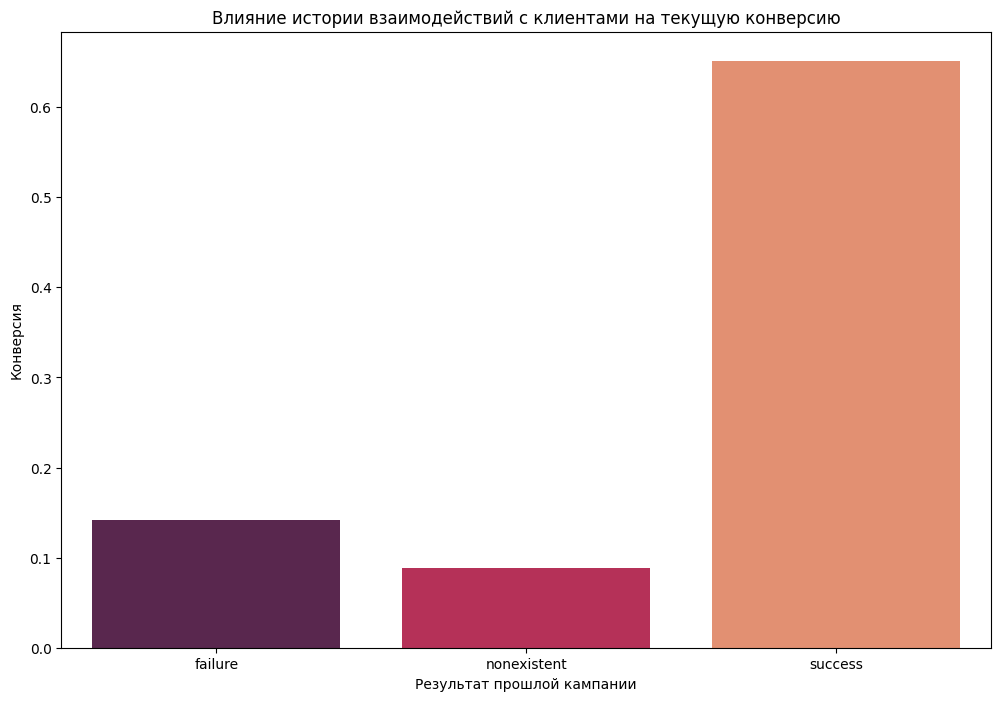

In [23]:
plt.figure(figsize=(12,8))
sns.barplot(df_outcomes, y='mean', x='poutcome', hue='poutcome', palette='rocket')

plt.title("Влияние истории взаимодействий с клиентами на текущую конверсию")
plt.ylabel("Конверсия")
plt.xlabel("Результат прошлой кампании")
plt.show()

Вывод по графику: если клиент уже оформлял депозит, то вероятность повторной сделки составляет до 65 процентов, что в 7 раз эффективнее работы с новыми клиентами. Также те, кто отказались в прошлый раз, показывают конверсию выше тех, кто является новым клиентом.
Бизнесу выгоднее сначала обрабатывать прошлых успешных клиентов, затем отказников, а потом только массовый обзвон новых людей. Это позволит снизить стоимость привлечения и повысить отдачу маркетинга

Гипотеза 5. Конверсия в депозиты напрямую зависит от рыночных ставок. Когда ставка растет - депозиты становятся привлекательнее

In [24]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,binary_y,age_group
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,Пожилой возраст(54-64)
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,Пожилой возраст(54-64)
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,Зрелый возраст (35-44)
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,Зрелый возраст (35-44)
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,Пожилой возраст(54-64)


Сгруппируем данные по месяцам  и посчитаем среднюю ставку и среднюю конверсию 

In [25]:
# в ручную зададим линейный порядок по месяцам, а не по алфавиту после аггрегации
months_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

df_euribor3m = df.groupby('month').agg({'binary_y': 'mean', 'euribor3m': 'mean'}).reset_index()
df_euribor3m['month'] = pd.Categorical(df_euribor3m['month'], categories=months_order, ordered=True)

df_euribor3m = df_euribor3m.sort_values('month')
df_euribor3m

,month,binary_y,euribor3m
5,mar,0.505495,1.162745
0,apr,0.204787,1.361070
6,may,0.064347,3.293665
4,jun,0.105115,4.256908
3,jul,0.090466,4.685678
1,aug,0.106021,4.300623
9,sep,0.449123,0.834760
8,oct,0.438719,1.200123
7,nov,0.101439,3.723123
2,dec,0.489011,0.865319


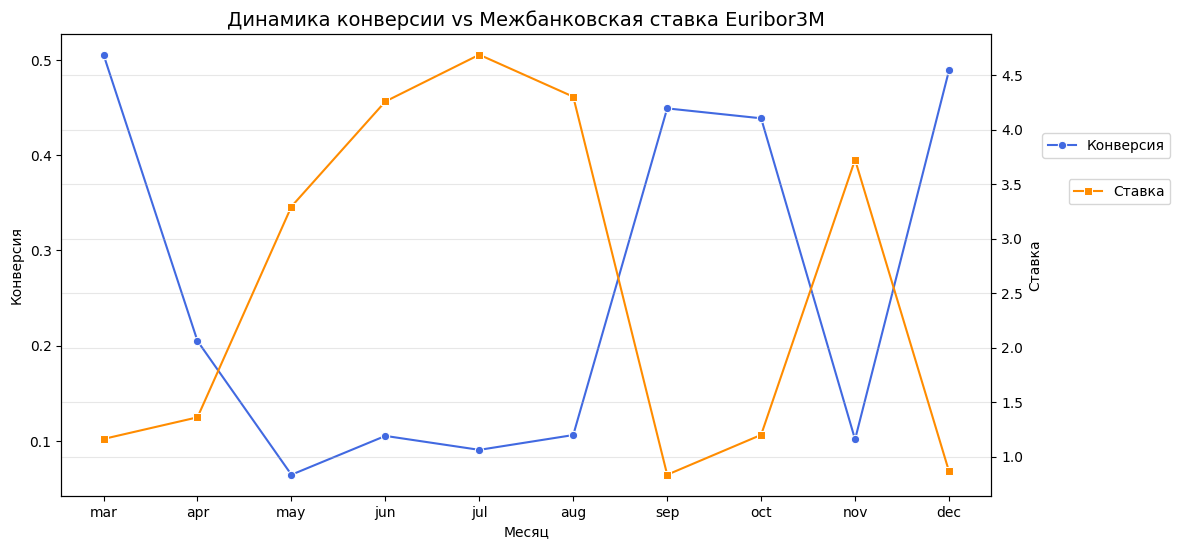

In [26]:
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=df_euribor3m, x='month', y='binary_y', ax=ax1, color='royalblue', marker='o', label="Конверсия")
ax1.set_ylabel("Конверсия")
ax1.set_xlabel("Месяц")
ax1.legend(bbox_to_anchor=(0.7, 0.3, 0.5, 0.5))

ax2 = ax1.twinx()
sns.lineplot(data=df_euribor3m, x='month', y='euribor3m', ax=ax2,color='darkorange', marker='s', label="Ставка")
ax2.set_ylabel("Ставка")
ax2.legend(bbox_to_anchor=(0.7, 0.2, 0.5, 0.5))

plt.title('Динамика конверсии vs Межбанковская ставка Euribor3M', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

Вывод по графику: в периоды высокой ставки конверсия остается минимальной, но как только ставка снижается, то интерес к депозитам резко возрастает. Когда рыночные ставки падают, клиенты стремятся «зафиксировать» текущую доходность по вкладам, опасаясь, что в ближайшем будущем условия станут еще менее выгодными.

Совет бизнесу: в период высоких ставок стоит предлагать гибкие депозиты с возможностью пересмотра ставки или краткосрочный продукт, чтобы зацепить клиентов
Следует увеличить рекламный бюджет в моменты падения индекса, чтобы максимально открыто привлечь ликвидность, так как клиенты психологически готовы закрывать сделки быстрее